# Data Understanding

Goal: Explore the cleaned base dataset and verify its quality before EDA and feature engineering.

Tasks:
- Load the dataset
- Check shape and columns
- Check data types
- Check the first five rows
- Check missing values
- Check duplicated rows
- Generate descriptive statistics

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [138]:
df = pd.read_csv("../dataset/cleaned_base_dataset.csv")
df.shape



(108614, 23)

In [139]:
df.dtypes

order_id                             str
order_item_id                      int64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
product_category_name                str
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
dtype: object

In [141]:
count_of_missing_values = df.isna().sum()
count_of_missing_values

order_id                         0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
dtype: int64

In [142]:
total_duplicates = df.duplicated().sum()
total_duplicates

np.int64(0)

In [143]:
df.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,108614.000000,108614.000000,108614.000000,108614.000000,108614.000000,108614.000000,108614.000000,108614.000000,108614.000000,108614.000000
mean,1.198648,120.063236,19.983139,48.807060,787.327729,2.210709,2095.524325,30.199357,16.586812,23.030917
std,0.708612,181.994363,15.734611,10.008349,651.394550,1.721848,3744.284295,16.158589,13.433700,11.698185
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,74.900000,16.290000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,134.900000,21.160000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


## 2. Convert Date Columns

The date columns are currently stored as strings.  
We convert them to datetime format so they can be used later for time-based analysis.

In [144]:
date_columns = [
    "shipping_limit_date",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])
    

In [145]:
df[date_columns].dtypes

shipping_limit_date              datetime64[us]
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

## 3. Create Simple Date Features

After converting date columns to datetime format, we extract simple time-based features such as year and month. These features may help us analyze whether product prices change over time.

In [146]:
df["purchase_year"] = df["order_purchase_timestamp"].dt.year
df["purchase_month"] = df["order_purchase_timestamp"].dt.month


In [147]:
df[["order_purchase_timestamp", "purchase_year", "purchase_month"]].head()

,order_purchase_timestamp,purchase_year,purchase_month
0,2017-09-13 08:59:02,2017,9
1,2017-04-26 10:53:06,2017,4
2,2018-01-14 14:33:31,2018,1
3,2018-08-08 10:00:35,2018,8
4,2017-02-04 13:57:51,2017,2


## 4. Target Variable Analysis: Price

In this step, we analyze the target variable `price` to understand its distribution, summary statistics, and possible outliers.

In [148]:
df['price'].describe()

count    108614.000000
mean        120.063236
std         181.994363
min           0.850000
25%          39.900000
50%          74.900000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

In [149]:
upper_limit = df['price'].quantile(0.99)
upper_limit

np.float64(887.0)

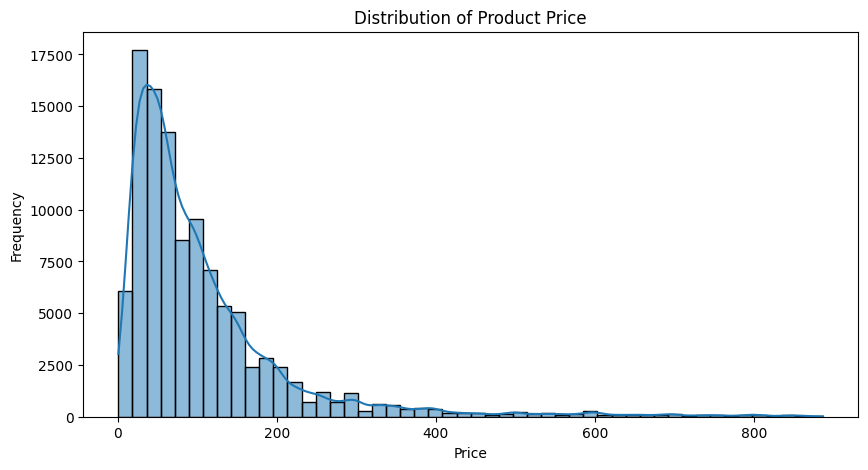

In [150]:
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] <= upper_limit]['price'], bins=50, kde=True)
plt.title('Distribution of Product Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

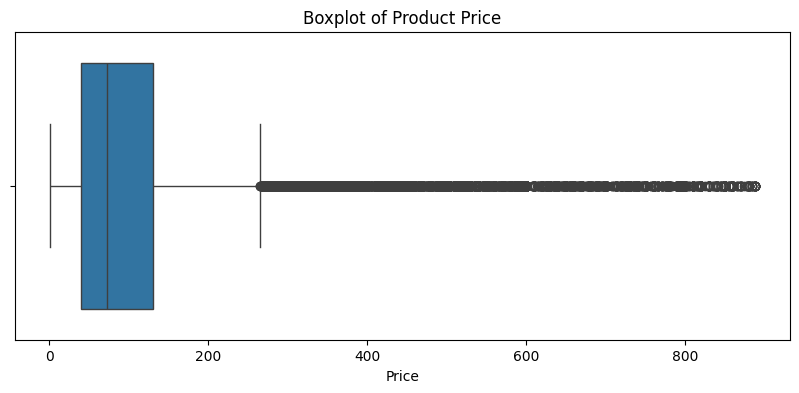

In [151]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df[df['price'] <= upper_limit]['price'])
plt.title('Boxplot of Product Price')
plt.xlabel('Price')
plt.show()

The original price distribution was difficult to interpret because a small number of very high prices stretched the x-axis. Therefore, we visualized the price distribution up to the 99th percentile, where 99% of product prices are less than or equal to 887.

## 5. Feature Relationship with Price

In this step, we explore how numerical features are related to the target variable `price`.

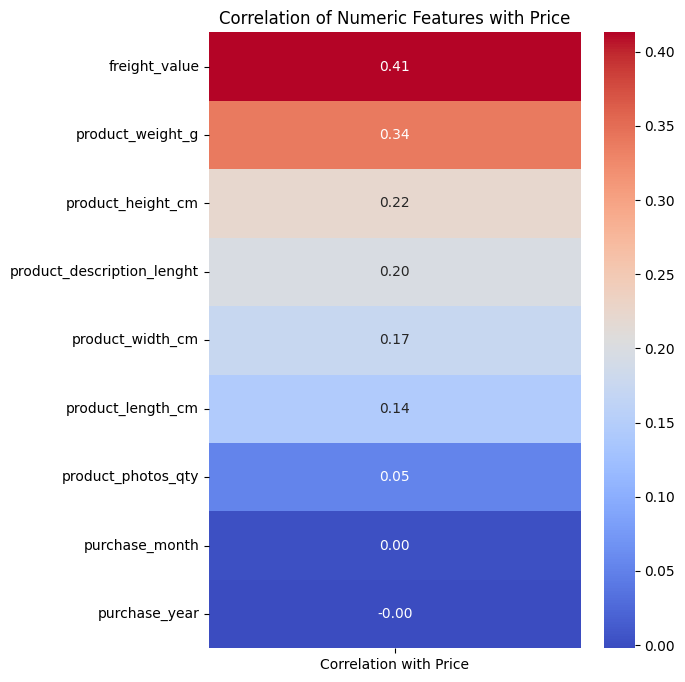

In [152]:
numeric_cols = [
    'freight_value',
    'product_weight_g',
    'product_description_lenght',
    'product_photos_qty',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'purchase_year',
    'purchase_month'
]

price_corr = df[numeric_cols].corrwith(df['price']).sort_values(ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(
    price_corr.to_frame(name='Correlation with Price'),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation of Numeric Features with Price')
plt.show()

## 6. Category Analysis with Price

In this step, we analyze the relationship between product categories and price. Since product category may strongly affect product price, we compare categories using count, mean, and median price.

In [159]:
category_price = df.groupby('product_category_name_english')['price'].agg(
    count='count',
    mean='mean',
    median='median'
).sort_values(by='median', ascending=False)

category_price.head(10)

,count,mean,median
product_category_name_english,,,
computers,199,1098.915276,1100.000
small_appliances_home_oven_and_coffee,73,638.213151,640.990
agro_industry_and_commerce,206,342.553883,243.750
home_appliances_2,231,467.333117,227.990
furniture_bedroom,103,184.968932,179.000
office_furniture,1668,160.763975,144.940
security_and_services,2,141.645000,141.645
air_conditioning,289,184.510588,139.990
la_cuisine,14,146.785000,137.000


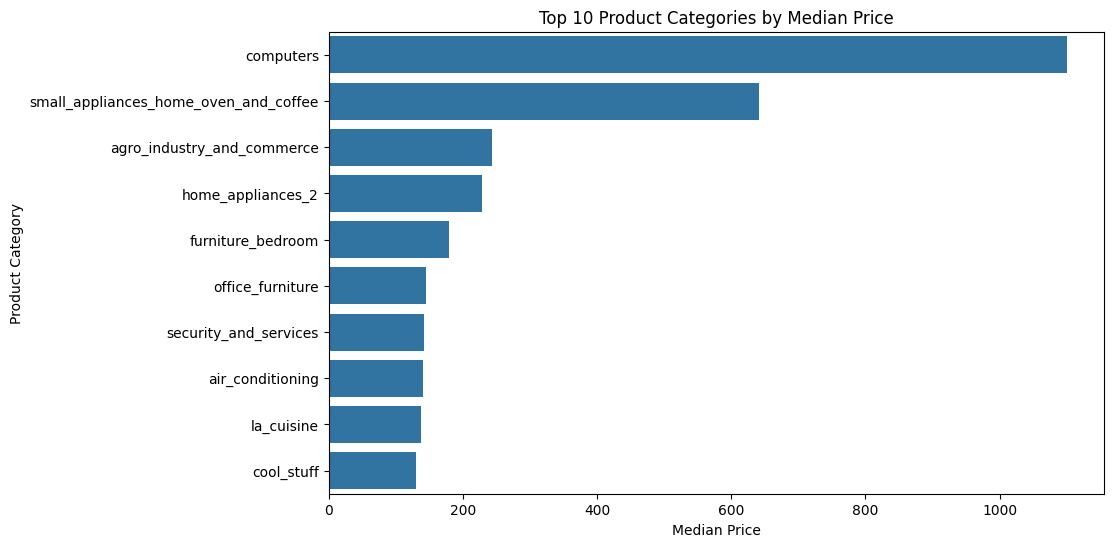

In [161]:
top_categories = category_price.head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_categories,
    x='median',
    y='product_category_name_english'
)

plt.title('Top 10 Product Categories by Median Price')
plt.xlabel('Median Price')
plt.ylabel('Product Category')
plt.show()

The category analysis shows that product prices vary across product categories. Some categories have noticeably higher median prices than others, which suggests that product category is likely an important feature for price prediction.

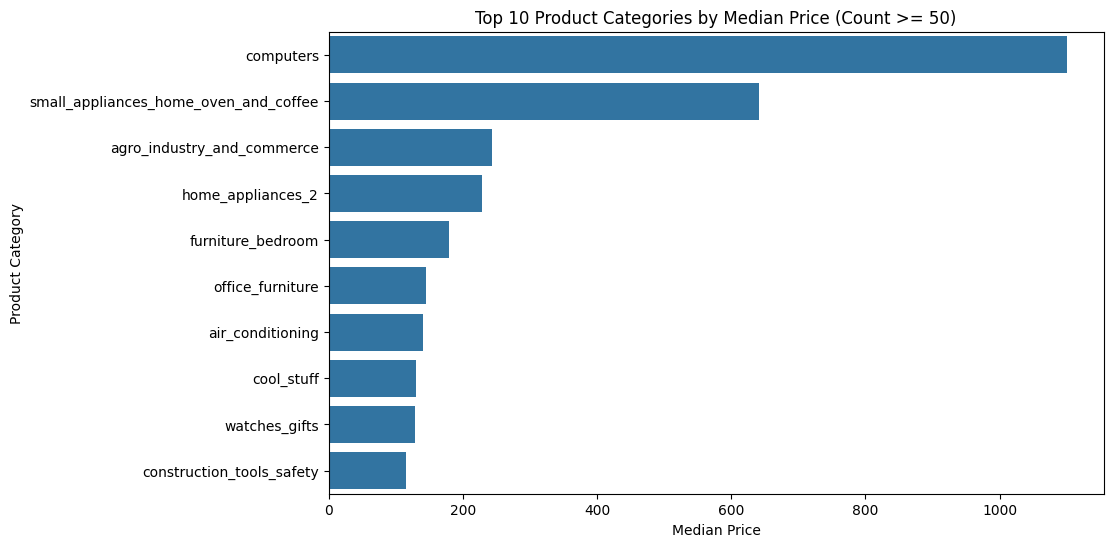

In [162]:
category_price_filtered = category_price[category_price['count'] >= 50]

top_categories_filtered = category_price_filtered.head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_categories_filtered,
    x='median',
    y='product_category_name_english'
)

plt.title('Top 10 Product Categories by Median Price (Count >= 50)')
plt.xlabel('Median Price')
plt.ylabel('Product Category')
plt.show()

The category analysis shows that median price varies across product categories. However, categories with very small counts may produce unreliable median values. Therefore, we also analyzed categories with at least 50 records to obtain a more reliable comparison.

## Data Understanding Summary

The dataset contains 108,614 rows and 23 columns, with no missing values or duplicated rows. Date columns were converted to datetime format, and simple time features were created from the purchase timestamp.

The target variable `price` is highly right-skewed, with most products having relatively low prices and a small number of products having very high prices. To better visualize the distribution, the price was also plotted up to the 99th percentile.

Correlation analysis showed that some numerical features such as freight value and product weight have a moderate positive relationship with price, while other numerical features have weaker relationships. Category analysis also showed that product prices vary across categories, suggesting that product category may be an important feature for price prediction.